# Deforestación Perú — Entrenar la U-Net (detección de cambio)

**Proyecto final MIA-07** — Detección de deforestación con U-Net.

Lee el split de `04_dataset_parches.ipynb` (`data/train/dataset_split_cd.json`), reconstruye los `DataLoader`, entrena una **U-Net** que toma el par **antes+después apilado (8 canales: R,G,B,NIR × 2) 128×128** y predice una **máscara binaria** del cambio (deforestación del período FESATA→FESATB).

- **Por qué 8 canales (detección de cambio):** una sola imagen no distingue clareo nuevo de clareo viejo (ambos son suelo desnudo). Con antes (bosque) + después (clareado) el modelo aprende el cambio verde→café, que es justo lo que marca el polígono SERFOR.
- **Loss = Dice + BCE.** La deforestación es pocos % de los píxeles, así que la *accuracy* engaña. Dice mira el solape con la clase positiva; BCE estabiliza el entrenamiento.
- **Métricas en test: IoU y F1 sobre la clase deforestación**, no accuracy.
- Guardamos los mejores pesos por **IoU de validación** en `data/unet_cd_best.pt`.

## 1. Dependencias y almacenamiento

In [ ]:
!pip install -q rasterio opencv-python-headless torch segmentation-models-pytorch

from pathlib import Path

try:
    from google.colab import drive
    drive.mount("/content/drive")
    BASE_DIR = Path("/content/drive/MyDrive/deforestacion-peru")
except ImportError:
    BASE_DIR = Path(".")

DATA_DIR   = BASE_DIR / "data"
SPLIT_PATH = DATA_DIR / "train" / "dataset_split_cd.json"   # split before/after
CKPT_PATH  = DATA_DIR / "unet_8band_best.pt"                # pesos de ESTE experimento
print("Split:", SPLIT_PATH, "| existe:", SPLIT_PATH.exists())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 14.1 MB/s eta 0:00:00
Mounted at /content/drive
Split: /content/drive/MyDrive/deforestacion-peru/data/train/dataset_split_cd.json | existe: True


## 2. Cargar el split y reconstruir los DataLoader

Reusamos exactamente el dataset de `04`: lee el `.tif` 4-band, normaliza dividiendo por 10000 (reflectancia L2A → [0,1]), redimensiona a 128×128 (imagen bilineal, máscara vecino más cercano) y aplica flips solo en train. El split ya viene decidido por escena en el JSON, así que no hay leakage.

In [ ]:
import json, shutil
import numpy as np
import rasterio
import cv2
import torch
from torch.utils.data import Dataset, DataLoader

SIZE = 128
pairs = json.loads(SPLIT_PATH.read_text())

# --- STAGING A DISCO LOCAL --------------------------------------------------
# Leer los .tif directo de Drive (FUSE/red) deja el GPU OCIOSO esperando IO.
# Copiamos sentinel_cd/ y masks_cd/ a /content (SSD local) y remapeamos rutas.
SRC_DATA   = str(DATA_DIR)
LOCAL_DATA = "/content/data_local"
def _stage(subdir):
    s = Path(SRC_DATA) / subdir; d = Path(LOCAL_DATA) / subdir
    if not s.exists(): return
    d.mkdir(parents=True, exist_ok=True)
    for f in s.glob("*.tif"):
        df = d / f.name
        if not df.exists(): shutil.copy(f, df)
if Path("/content").exists():
    for sub in ["sentinel_cd", "masks_cd"]:
        _stage(sub)
    for it in pairs:
        for k in ("antes", "despues", "mask"):
            it[k] = it[k].replace(SRC_DATA, LOCAL_DATA)
    print("Data copiada a", LOCAL_DATA, "(lecturas locales rápidas)")

class DeforestDataset(Dataset):
    """Detección de cambio, 8 canales: antes (4) + después (4) RGBN."""
    def __init__(self, items, size=SIZE, augment=False):
        self.items = items
        self.size = size
        self.augment = augment

    def __len__(self):
        return len(self.items)

    def __getitem__(self, i):
        it = self.items[i]
        with rasterio.open(it["antes"]) as src:
            a = src.read().astype("float32")             # (4, H, W)
        with rasterio.open(it["despues"]) as src:
            b = src.read().astype("float32")             # (4, H, W)
        with rasterio.open(it["mask"]) as src:
            mask = src.read(1).astype("float32")          # (H, W)

        a = cv2.resize(np.transpose(a, (1, 2, 0)), (self.size, self.size),
                       interpolation=cv2.INTER_LINEAR)
        b = cv2.resize(np.transpose(b, (1, 2, 0)), (self.size, self.size),
                       interpolation=cv2.INTER_LINEAR)
        mask = cv2.resize(mask, (self.size, self.size), interpolation=cv2.INTER_NEAREST)

        img = np.concatenate([a, b], axis=2)              # (H,W,8)
        img = np.clip(img / 10000.0, 0, 1)                # reflectancia L2A -> [0,1]

        if self.augment:
            if np.random.rand() < 0.5:
                img = img[:, ::-1, :].copy();  mask = mask[:, ::-1].copy()
            if np.random.rand() < 0.5:
                img = img[::-1, :, :].copy();  mask = mask[::-1, :].copy()

        img = torch.from_numpy(np.ascontiguousarray(np.transpose(img, (2, 0, 1))))  # (8,128,128)
        mask = torch.from_numpy(np.ascontiguousarray(mask)).unsqueeze(0)            # (1,128,128)
        return img, mask

BATCH = 64
def make_loader(split, augment=False, shuffle=False):
    items = [p for p in pairs if p["split"] == split]
    ds = DeforestDataset(items, augment=augment)
    return DataLoader(ds, batch_size=BATCH, shuffle=shuffle, num_workers=4,
                      pin_memory=True, persistent_workers=True, prefetch_factor=4)

train_loader = make_loader("train", augment=True, shuffle=True)
val_loader   = make_loader("val")
test_loader  = make_loader("test")

from collections import Counter
c = Counter(p["split"] for p in pairs)
print(f"Pares: {len(pairs)} | train={c['train']} val={c['val']} test={c['test']} | batch={BATCH} | canales=8")

pos = tot = 0
for _, yb in train_loader:
    pos += float(yb.sum()); tot += yb.numel()
frac = pos / tot
print(f"% píxeles deforestados en train: {100*frac:.2f}%")

Data copiada a /content/data_local (lecturas locales rápidas)
Pares: 1039 | train=727 val=156 test=156 | batch=64 | canales=8
% píxeles deforestados en train: 2.89%


## 3. La U-Net (encoder ResNet34 pre-entrenado)

Usamos `segmentation-models-pytorch` (smp) para armar una **U-Net con encoder ResNet34 pre-entrenado en ImageNet** (transfer learning):

- **Encoder = ResNet34** ya entrenado en ImageNet → arranca sabiendo detectar bordes, texturas y formas. No reaprende eso desde cero.
- **Entrada: 4 canales** (R, G, B, NIR). El encoder original es RGB (3 canales); smp adapta el primer conv a 4 canales automáticamente (`in_channels=4`), inicializando la banda extra (NIR) desde los pesos pre-entrenados.
- **Salida: 1 canal** (logits). `sigmoid` al evaluar.
- El **decoder** sí se entrena desde cero — es el que aprende a marcar deforestación con tus datos.

Frente a una U-Net desde cero, esto suele dar **mejor IoU con menos epochs**, sobre todo con datasets medianos como el tuyo (~1800 pares).

In [ ]:
import torch.nn as nn
import segmentation_models_pytorch as smp

device = "cuda" if torch.cuda.is_available() else "cpu"

model = smp.Unet(
    encoder_name="resnet34",        # encoder ResNet34
    encoder_weights="imagenet",     # pre-entrenado en ImageNet (transfer learning)
    in_channels=8,                  # 4 antes + 4 después (R,G,B,NIR x2)
    classes=1,                      # 1 máscara binaria (logits)
).to(device)

n_par = sum(p.numel() for p in model.parameters())
n_train_par = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Device: {device} | parámetros: {n_par/1e6:.2f} M (entrenables: {n_train_par/1e6:.2f} M)")

with torch.no_grad():
    xb, _ = next(iter(val_loader))
    out = model(xb.to(device))
print("entrada:", tuple(xb.shape), "-> salida:", tuple(out.shape))   # (B,8,128,128) -> (B,1,128,128)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Device: cuda | parámetros: 24.45 M (entrenables: 24.45 M)
entrada: (64, 8, 128, 128) -> salida: (64, 1, 128, 128)


## 4. Loss (Dice + BCE) y métricas

- **BCE con `pos_weight`**: pesa más los píxeles positivos (raros) para que el modelo no aprenda a apagar todo.
- **Dice loss**: `1 - 2|A∩B| / (|A|+|B|)`, optimiza directamente el solape con la clase deforestación.
- **Métricas** (sobre la clase positiva, con umbral 0.5): IoU, F1, precision, recall. Las calculamos acumulando intersección y unión sobre todo el set — no promediando por batch — para que sea el valor real del dataset.

In [ ]:
class DiceBCELoss(nn.Module):
    def __init__(self, pos_weight=None, smooth=1.0):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        self.smooth = smooth
    def forward(self, logits, target):
        bce = self.bce(logits, target)
        prob = torch.sigmoid(logits)
        num = 2 * (prob * target).sum(dim=(1,2,3)) + self.smooth
        den = prob.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3)) + self.smooth
        dice = 1 - (num / den).mean()
        return bce + dice

# pos_weight = (neg/pos): cuántas veces más raro es el positivo
pw = torch.tensor([(1 - frac) / max(frac, 1e-6)], device=device)
criterion = DiceBCELoss(pos_weight=pw)
print("pos_weight:", round(float(pw), 1))

@torch.no_grad()
def evaluate(loader, thr=0.5):
    model.eval()
    inter = union = tp = fp = fn = 0.0
    loss_sum = n = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss_sum += float(criterion(logits, yb)) * xb.size(0); n += xb.size(0)
        pred = (torch.sigmoid(logits) > thr).float()
        inter += float((pred * yb).sum())
        union += float(((pred + yb) >= 1).sum())
        tp += float((pred * yb).sum())
        fp += float((pred * (1 - yb)).sum())
        fn += float(((1 - pred) * yb).sum())
    iou  = inter / (union + 1e-6)
    prec = tp / (tp + fp + 1e-6)
    rec  = tp / (tp + fn + 1e-6)
    f1   = 2 * prec * rec / (prec + rec + 1e-6)
    return {"loss": loss_sum / n, "iou": iou, "f1": f1, "precision": prec, "recall": rec}

pos_weight: 33.6


## 5. Entrenamiento

Adam + scheduler que baja el LR cuando el IoU de validación se estanca. Guardamos los pesos del **mejor IoU de validación** (no del último epoch) en `data/unet_best.pt`.

In [ ]:
EPOCHS = 100
RESUME_PATH = DATA_DIR / "unet_8band_resume.pt"   # estado COMPLETO para reanudar (propio)
SAVE_RESUME_EVERY = 5
RESET = True                                       # arranca de 0

opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="max", factor=0.5, patience=4)

history = {"train_loss": [], "val_loss": [], "val_iou": [], "val_f1": []}
best_iou = -1.0
start_epoch = 1

if RESET and RESUME_PATH.exists():
    RESUME_PATH.unlink(); print("RESET=True -> borrado el resume, arranco de 0")
elif RESUME_PATH.exists():
    ck = torch.load(str(RESUME_PATH), map_location=device)
    model.load_state_dict(ck["model"])
    opt.load_state_dict(ck["opt"])
    sched.load_state_dict(ck["sched"])
    history = ck["history"]; best_iou = ck["best_iou"]; start_epoch = ck["epoch"] + 1
    print(f"Reanudando desde epoch {start_epoch} (best_iou={best_iou:.3f})")

for epoch in range(start_epoch, EPOCHS + 1):
    model.train()
    run = n = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        opt.step()
        run += float(loss) * xb.size(0); n += xb.size(0)
    tr_loss = run / n

    val = evaluate(val_loader)
    sched.step(val["iou"])
    history["train_loss"].append(tr_loss)
    history["val_loss"].append(val["loss"])
    history["val_iou"].append(val["iou"])
    history["val_f1"].append(val["f1"])

    flag = ""
    if val["iou"] > best_iou:
        best_iou = val["iou"]
        torch.save(model.state_dict(), str(CKPT_PATH))
        flag = "  <- mejor (guardado)"
    print(f"epoch {epoch:3d} | train {tr_loss:.3f} | val loss {val['loss']:.3f} "
          f"IoU {val['iou']:.3f} F1 {val['f1']:.3f}{flag}")

    if epoch % SAVE_RESUME_EVERY == 0 or epoch == EPOCHS:
        torch.save({"epoch": epoch, "model": model.state_dict(), "opt": opt.state_dict(),
                    "sched": sched.state_dict(), "history": history, "best_iou": best_iou},
                   str(RESUME_PATH))

print(f"\nMejor IoU val: {best_iou:.3f} -> {CKPT_PATH}")

/tmp/ipykernel_491/3712726203.py:32: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  run += float(loss) * xb.size(0); n += xb.size(0)


epoch   1 | train 1.928 | val loss 2.866 IoU 0.028 F1 0.055  <- mejor (guardado)
epoch   2 | train 1.573 | val loss 2.500 IoU 0.032 F1 0.061  <- mejor (guardado)
epoch   3 | train 1.441 | val loss 1.952 IoU 0.059 F1 0.111  <- mejor (guardado)
epoch   4 | train 1.319 | val loss 1.588 IoU 0.194 F1 0.325  <- mejor (guardado)
epoch   5 | train 1.215 | val loss 1.463 IoU 0.133 F1 0.234
epoch   6 | train 1.215 | val loss 1.513 IoU 0.163 F1 0.280
epoch   7 | train 1.188 | val loss 1.672 IoU 0.166 F1 0.285
epoch   8 | train 1.157 | val loss 1.511 IoU 0.158 F1 0.274
epoch   9 | train 1.104 | val loss 1.549 IoU 0.096 F1 0.175
epoch  10 | train 1.063 | val loss 1.286 IoU 0.162 F1 0.279
epoch  11 | train 1.027 | val loss 1.343 IoU 0.227 F1 0.370  <- mejor (guardado)
epoch  12 | train 0.992 | val loss 1.233 IoU 0.232 F1 0.377  <- mejor (guardado)
epoch  13 | train 0.963 | val loss 1.395 IoU 0.218 F1 0.358
epoch  14 | train 0.951 | val loss 1.265 IoU 0.230 F1 0.374
epoch  15 | train 0.924 | val loss

## 6. Curvas de entrenamiento

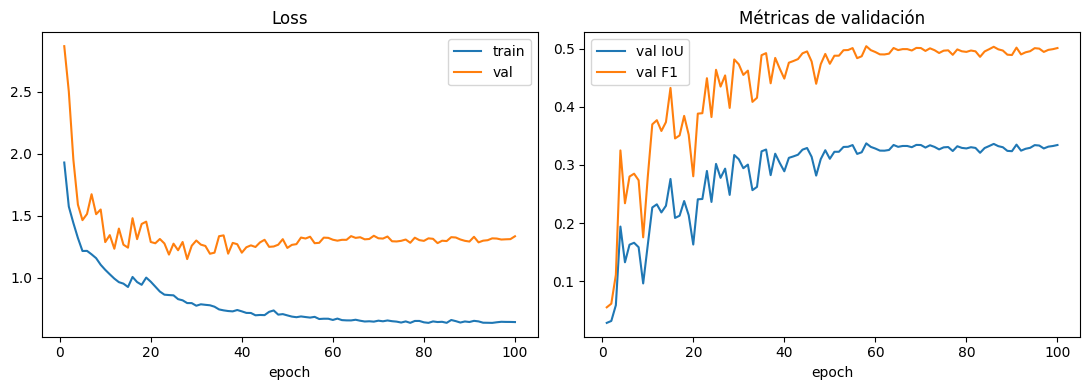

In [ ]:
import matplotlib.pyplot as plt

ep = range(1, len(history["train_loss"]) + 1)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(ep, history["train_loss"], label="train")
ax[0].plot(ep, history["val_loss"], label="val")
ax[0].set_title("Loss"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].plot(ep, history["val_iou"], label="val IoU")
ax[1].plot(ep, history["val_f1"], label="val F1")
ax[1].set_title("Métricas de validación"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.tight_layout(); plt.savefig(str(DATA_DIR / "unet_curvas.png"), dpi=110, bbox_inches="tight"); plt.show()

## 7. Evaluación en test

Cargamos los mejores pesos y medimos sobre el set de test (escenas que el modelo nunca vio). Estos son los números que reportas.

In [ ]:
model.load_state_dict(torch.load(str(CKPT_PATH), map_location=device))
test = evaluate(test_loader)
print("=== TEST (clase deforestación) ===")
for k in ["iou", "f1", "precision", "recall", "loss"]:
    print(f"  {k:10s}: {test[k]:.3f}")

=== TEST (clase deforestación) ===
  iou       : 0.360
  f1        : 0.529
  precision : 0.404
  recall    : 0.765
  loss      : 1.598


### Barrido de umbral

El umbral 0.5 no siempre es el mejor para clases desbalanceadas. Probamos varios y vemos cuál maximiza el F1 — útil si quieres priorizar recall (no perder deforestación) sobre precision.

In [ ]:
for thr in [0.3, 0.4, 0.5, 0.6, 0.7]:
    m = evaluate(test_loader, thr=thr)
    print(f"thr {thr:.1f} | IoU {m['iou']:.3f} F1 {m['f1']:.3f} "
          f"P {m['precision']:.3f} R {m['recall']:.3f}")

thr 0.3 | IoU 0.334 F1 0.501 P 0.366 R 0.792
thr 0.4 | IoU 0.348 F1 0.516 P 0.386 R 0.778
thr 0.5 | IoU 0.360 F1 0.529 P 0.404 R 0.765
thr 0.6 | IoU 0.371 F1 0.541 P 0.423 R 0.751
thr 0.7 | IoU 0.381 F1 0.552 P 0.443 R 0.733


In [ ]:
# === GUARDAR EXPERIMENTO (corre DESPUÉS de entrenar y evaluar) ==============
import json, shutil, csv

EXP_NAME    = "resnet34_e100_8band"
ENCODER     = "resnet34"
IN_CHANNELS = 8
EXP_DIR  = DATA_DIR / "experiments" / EXP_NAME
EXP_DIR.mkdir(parents=True, exist_ok=True)

shutil.copy(str(CKPT_PATH), str(EXP_DIR / "unet_best.pt"))

ep = range(1, len(history["train_loss"]) + 1)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(ep, history["train_loss"], label="train"); ax[0].plot(ep, history["val_loss"], label="val")
ax[0].set_title("Loss"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].plot(ep, history["val_iou"], label="val IoU"); ax[1].plot(ep, history["val_f1"], label="val F1")
ax[1].set_title("Métricas val"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.tight_layout(); plt.savefig(str(EXP_DIR / "curvas.png"), dpi=110, bbox_inches="tight"); plt.close()

model.load_state_dict(torch.load(str(CKPT_PATH), map_location=device))
test_by_thr = {f"{t:.1f}": evaluate(test_loader, thr=t) for t in [0.3, 0.4, 0.5, 0.6, 0.7]}
best_thr = max(test_by_thr, key=lambda t: test_by_thr[t]["f1"])
metrics = {
    "exp": EXP_NAME, "encoder": ENCODER, "in_channels": IN_CHANNELS, "batch": BATCH,
    "epochs_corridos": len(history["val_iou"]),
    "best_val_iou": max(history["val_iou"]),
    "test_thr05": test_by_thr["0.5"],
    "best_thr": best_thr, "test_best_thr": test_by_thr[best_thr],
    "test_por_umbral": test_by_thr, "history": history,
}
(EXP_DIR / "metrics.json").write_text(json.dumps(metrics, indent=2))

RES_CSV = DATA_DIR / "experiments" / "results.csv"
row = {"exp": EXP_NAME, "encoder": ENCODER, "in_channels": IN_CHANNELS,
       "epochs": metrics["epochs_corridos"], "batch": BATCH,
       "best_val_iou": round(metrics["best_val_iou"], 3),
       "test_iou@0.5": round(test_by_thr["0.5"]["iou"], 3),
       "test_f1@0.5": round(test_by_thr["0.5"]["f1"], 3),
       "best_thr": best_thr,
       "test_iou@best": round(test_by_thr[best_thr]["iou"], 3),
       "test_f1@best": round(test_by_thr[best_thr]["f1"], 3)}
write_header = not RES_CSV.exists()
with open(RES_CSV, "a", newline="") as f:
    w = csv.DictWriter(f, fieldnames=list(row.keys()))
    if write_header: w.writeheader()
    w.writerow(row)

print(f"Experimento guardado en: {EXP_DIR}")
print(f"\nResumen: best_val_iou={metrics['best_val_iou']:.3f} | "
      f"test IoU@0.5={test_by_thr['0.5']['iou']:.3f} | "
      f"test IoU@{best_thr}={test_by_thr[best_thr]['iou']:.3f} (mejor umbral)")

Experimento guardado en: /content/drive/MyDrive/deforestacion-peru/data/experiments/resnet34_e100_8band

Resumen: best_val_iou=0.337 | test IoU@0.5=0.360 | test IoU@0.7=0.381 (mejor umbral)


## 8. Predicciones visuales (test)

In [ ]:
def stretch(a, lo=2, hi=98):
    a = a.astype("float32"); pl, ph = np.percentile(a, [lo, hi])
    return np.clip((a - pl) / (ph - pl + 1e-6), 0, 1)

model.eval()
xb, yb = next(iter(test_loader))
with torch.no_grad():
    pred = (torch.sigmoid(model(xb.to(device))) > 0.5).float().cpu()

k = min(4, xb.shape[0])
fig, axes = plt.subplots(k, 4, figsize=(13, 3.3 * k))
axes = np.atleast_2d(axes)
for row, img, gt, pr in zip(axes, xb[:k], yb[:k], pred[:k]):
    arr = img.numpy()
    rgb_a = np.dstack([stretch(arr[c]) for c in range(3)])      # canales 0-2 = antes
    rgb_b = np.dstack([stretch(arr[c]) for c in range(4, 7)])   # canales 4-6 = después
    row[0].imshow(rgb_a); row[0].set_title("ANTES", fontsize=9)
    row[1].imshow(rgb_b); row[1].set_title("DESPUÉS", fontsize=9)
    row[2].imshow(rgb_b); row[2].imshow(gt[0], cmap="Reds", alpha=0.45, vmin=0, vmax=1)
    row[2].set_title("Verdad (máscara)", fontsize=9)
    row[3].imshow(rgb_b); row[3].imshow(pr[0], cmap="Blues", alpha=0.45, vmin=0, vmax=1)
    row[3].set_title("Predicción U-Net", fontsize=9)
    for a in row: a.axis("off")
plt.tight_layout(); plt.savefig(str(DATA_DIR / "unet_cd_pred_muestra.png"), dpi=110, bbox_inches="tight"); plt.show()

Output hidden; open in https://colab.research.google.com to view.

## 9. Próximos pasos

Modelo entrenado y evaluado. Pesos en `data/unet_best.pt`.

- **NDVI como 5ta banda**: `(NIR - R) / (NIR + R)` separa bosque vivo de suelo desnudo; suele subir el IoU. Cambiarías `in_ch=5` en la U-Net y agregarías la banda en el dataset.
- **Más augmentation**: rotaciones 90°, pequeños cambios de brillo.
- **Encoder más grande** (resnet50, efficientnet-b0) si el IoU se estanca y la GPU aguanta. Solo cambias `encoder_name`.
- **Comparar contra U-Net desde cero**: entrena las dos y pon una tabla IoU/F1 — buen argumento para la tesis (muestra que transfer learning ayuda).
- **Análisis de errores**: mirar las escenas de test con peor IoU — suelen ser nubes o bordes de polígono mal rasterizados en `03`.